# **Prédiction du Comportement des Clients Bancaires - Bank Customer Behavior**

## *__Phase 1__ : Analyse Exploratoire & Preprocessing*

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
os.makedirs('../data/processed', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Chargement du Dataset

In [2]:
df = pd.read_csv(r'../data/bank-additional/bank-additional-full.csv', sep=';')
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Shape : (41188, 21)
Colonnes : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Analyse Exploratoire (EDA)

In [3]:
# Informations générales
print(" Infos générales")
df.info()
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")

 Infos générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx 

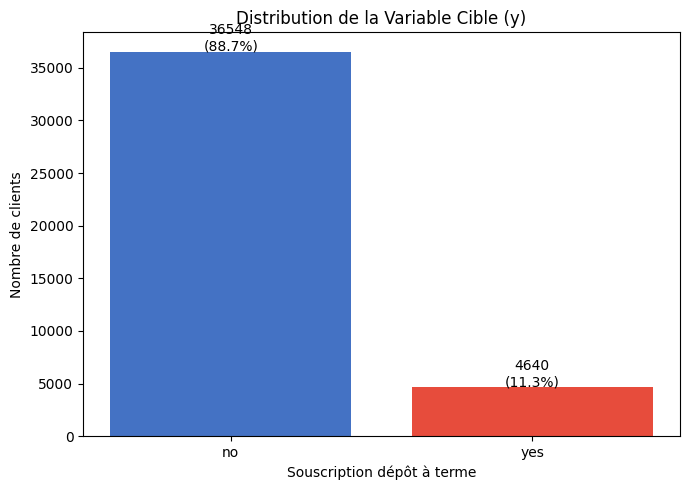

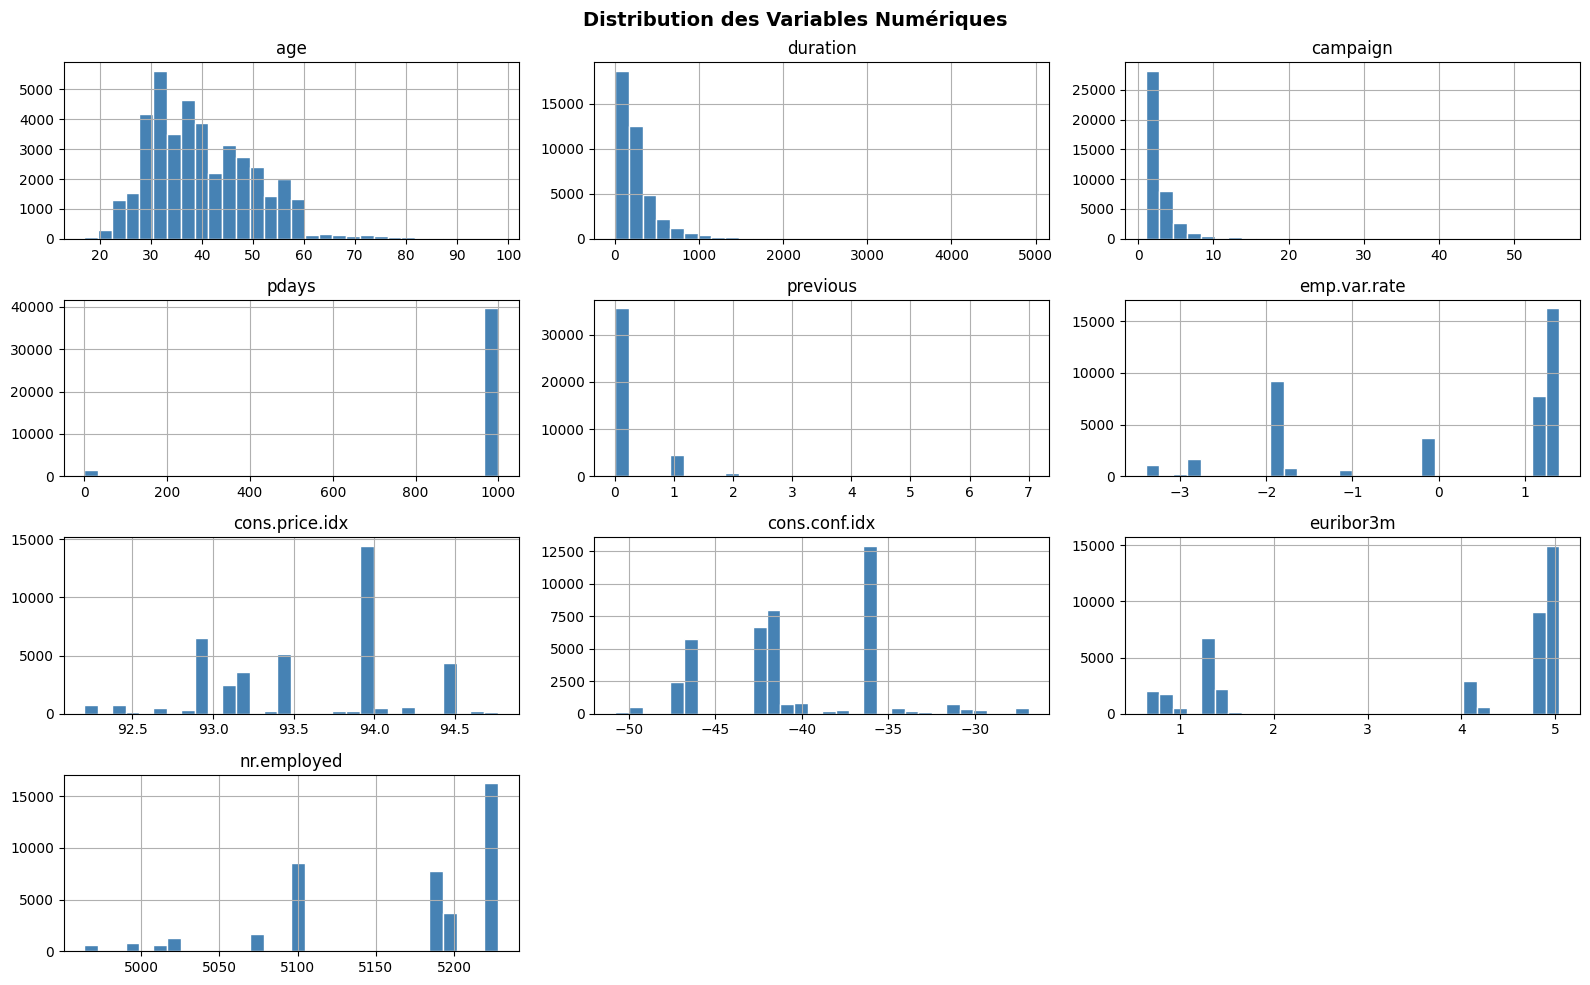

In [4]:
# Distribution de la variable cible
target_counts = df['y'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(target_counts.index, target_counts.values, color=['#4472C4','#E74C3C'])
ax.set_title('Distribution de la Variable Cible (y)')
ax.set_xlabel('Souscription dépôt à terme')
ax.set_ylabel('Nombre de clients')
for i, (idx, val) in enumerate(target_counts.items()):
    ax.text(i, val + 100, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../results/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Histogrammes variables numériques (graphe séparé)
df.select_dtypes(include=[np.number]).hist(bins=30, figsize=(16, 10),
                                            color='steelblue', edgecolor='white')
plt.suptitle('Distribution des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

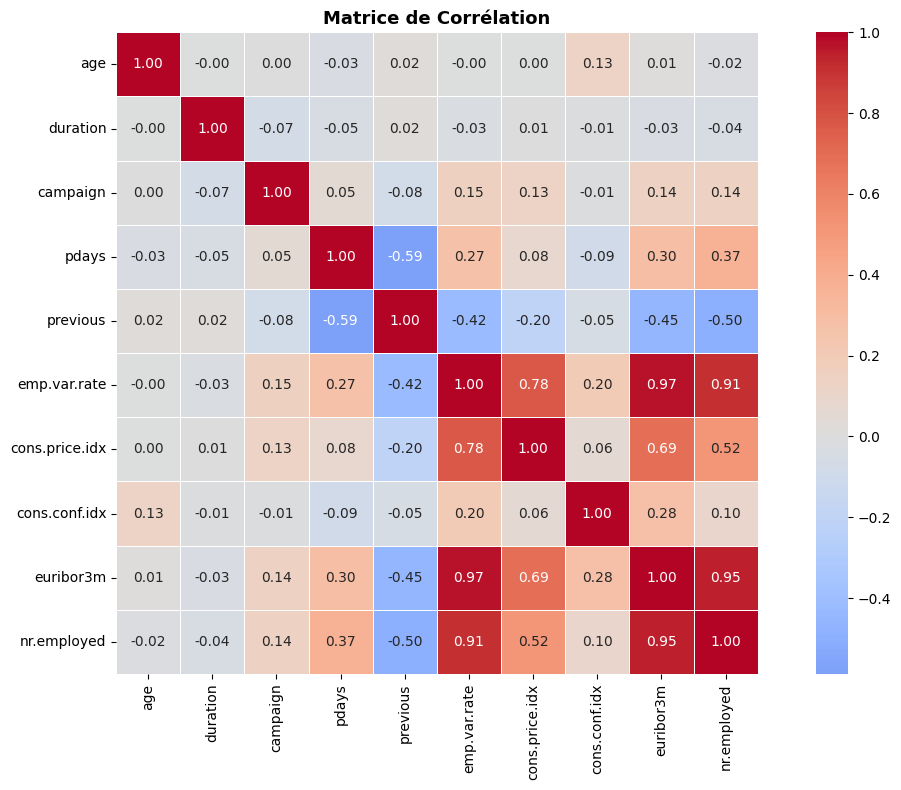

In [5]:
# Corrélations
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de Corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


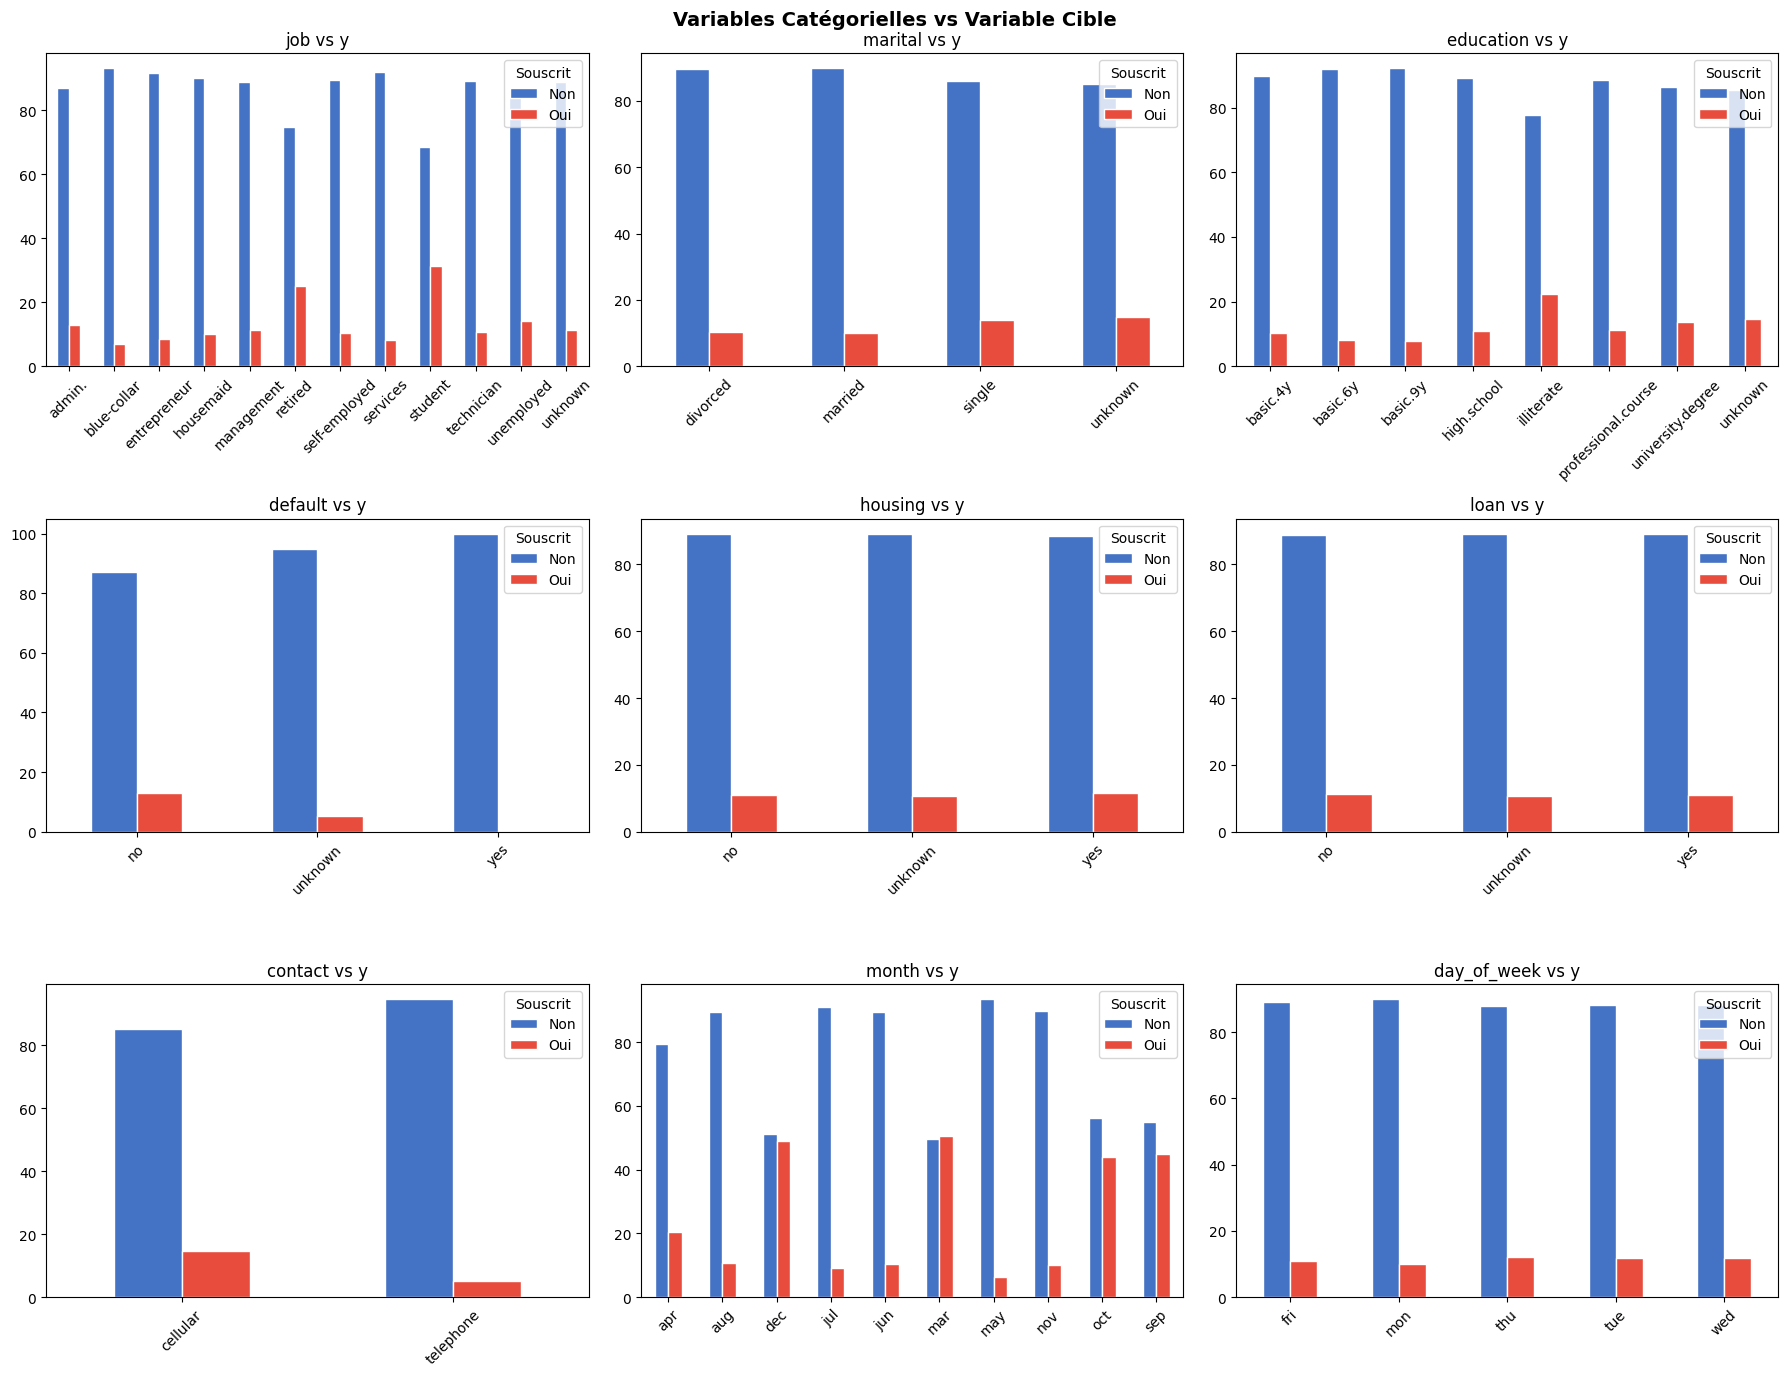

In [6]:
# Variables catégorielles vs cible
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
print(f"Variables catégorielles : {cat_cols}")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:9]):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4472C4','#E74C3C'], edgecolor='white')
    axes[i].set_title(f'{col} vs y')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['Non', 'Oui'], title='Souscrit')
plt.suptitle('Variables Catégorielles vs Variable Cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_categoricals.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [7]:
df_clean = df.copy()

# Encodage de la cible
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)
print(f"Cible encodée : {df_clean['y'].value_counts().to_dict()}")

# Transformation pdays en binaire (999 = jamais contacté)
df_clean['pdays_contacted'] = (df_clean['pdays'] != 999).astype(int)
df_clean.drop('pdays', axis=1, inplace=True)
print(f"pdays -> pdays_contacted : {df_clean['pdays_contacted'].value_counts().to_dict()}")

# Suppression de duration (non disponible avant l'appel -> inutilisable en production)
df_clean.drop('duration', axis=1, inplace=True)
print("duration supprimée")

# Suppression de day_of_week (non discriminant)
df_clean.drop('day_of_week', axis=1, inplace=True)
print("day_of_week supprimée")

# Remplacement des 'unknown' par le mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace('unknown', np.nan)
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f"  {col} : valeurs manquantes remplacées par le mode")

# Suppression des doublons
print(f"\nDoublons supprimés : {df_clean.duplicated().sum()}")
df_clean.drop_duplicates(inplace=True)
print(f"Shape après nettoyage : {df_clean.shape}")

Cible encodée : {0: 36548, 1: 4640}
pdays -> pdays_contacted : {0: 39673, 1: 1515}
duration supprimée
day_of_week supprimée
  job : valeurs manquantes remplacées par le mode
  marital : valeurs manquantes remplacées par le mode
  education : valeurs manquantes remplacées par le mode
  default : valeurs manquantes remplacées par le mode
  housing : valeurs manquantes remplacées par le mode
  loan : valeurs manquantes remplacées par le mode

Doublons supprimés : 2767
Shape après nettoyage : (38421, 19)


In [8]:
# One-Hot Encoding des variables catégorielles
cat_cols_encode = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Colonnes à encoder : {cat_cols_encode}")

df_encoded = pd.get_dummies(df_clean, columns=cat_cols_encode, drop_first=True)
print(f"\nShape après encoding : {df_encoded.shape}")

Colonnes à encoder : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape après encoding : (38421, 43)


In [9]:
# Séparation features / cible
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f"Features : {X.shape[1]} | Observations : {X.shape[0]}")

# Split train/test (80/20 stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Déséquilibre train : {y_train.value_counts().to_dict()}")

Features : 42 | Observations : 38421

Train : (30736, 42) | Test : (7685, 42)
Déséquilibre train : {0: 27067, 1: 3669}


In [10]:
# SMOTE sur le train uniquement
print("Application de SMOTE...")
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE : {pd.Series(y_train_res).value_counts().to_dict()}")

Application de SMOTE...
Après SMOTE : {0: 27067, 1: 27067}


In [11]:
# Sauvegarde des données preprocessées
X_train_res.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
pd.DataFrame(y_train_res, columns=['y']).to_csv('../data/processed/y_train.csv', index=False)
pd.DataFrame(y_test).reset_index(drop=True).to_csv('../data/processed/y_test.csv', index=False)

# Sauvegarde des noms de colonnes
pd.Series(X.columns.tolist()).to_csv('../data/processed/feature_names.csv', index=False)

print("Données sauvegardées dans data/processed/")
print(f" X_train : {X_train_res.shape}")
print(f" X_test : {X_test.shape}")

Données sauvegardées dans data/processed/
 X_train : (54134, 42)
 X_test : (7685, 42)


## *__Phase 2 :__ Classificateurs de Base*

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    average_precision_score, roc_curve,
    precision_score, recall_score
)
import shap

SEED = 42
np.random.seed(SEED)
os.makedirs('../models', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Chargement des Données

In [14]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Déséquilibre test : {pd.Series(y_test).value_counts().to_dict()}")

X_train : (54134, 42) | X_test : (7685, 42)
Déséquilibre test : {0: 6768, 1: 917}


## 2. Définition des Modèles

In [15]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arbre de Décision': DecisionTreeClassifier(max_depth=10, random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}
print(f"{len(models)} modèles définis.")

6 modèles définis.


## 3. Cross-Validation (5-Fold)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, clf in models.items():
    print(f"  Entraînement : {name}...", end=' ')
    scores = cross_validate(clf, X_train, y_train, cv=cv,
                            scoring=['roc_auc','f1','accuracy'],
                            n_jobs=-1, return_train_score=False)
    cv_results[name] = {
        'AUC-ROC (CV)': scores['test_roc_auc'].mean(),
        'F1 (CV)': scores['test_f1'].mean(),
        'Accuracy (CV)':scores['test_accuracy'].mean(),
    }
    print(f"AUC={scores['test_roc_auc'].mean():.4f} | F1={scores['test_f1'].mean():.4f}")

df_cv = pd.DataFrame(cv_results).T.sort_values('AUC-ROC (CV)', ascending=False)
print("\nRésultats Cross-Validation :")
display(df_cv.style.highlight_max(color="#088321").format('{:.4f}'))

  Entraînement : Régression Logistique... AUC=0.8991 | F1=0.8187
  Entraînement : Arbre de Décision... AUC=0.8815 | F1=0.7986
  Entraînement : Random Forest... AUC=0.9744 | F1=0.9235
  Entraînement : Gradient Boosting... AUC=0.9201 | F1=0.8409
  Entraînement : SVM... AUC=0.7656 | F1=0.7103
  Entraînement : KNN... AUC=0.9462 | F1=0.8859

Résultats Cross-Validation :


,AUC-ROC (CV),F1 (CV),Accuracy (CV)
Random Forest,0.9744,0.9235,0.9233
KNN,0.9462,0.8859,0.8790
Gradient Boosting,0.9201,0.8409,0.8492
Régression Logistique,0.8991,0.8187,0.8261
Arbre de Décision,0.8815,0.7986,0.8174
SVM,0.7656,0.7103,0.7108


## 4. Entraînement Final et Évaluation sur Test

In [ ]:
results_test = {}
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:,1]
    y_pred = clf.predict(X_test)

    results_test[name] = {
    'Modèle': name,
    'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
    'F1-Score': round(f1_score(y_test, y_pred), 4),
    'Précision': round(precision_score(y_test, y_pred), 4),
    'Recall': round(recall_score(y_test, y_pred), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'Avg Precision': round(average_precision_score(y_test, y_prob), 4),
}
    trained_models[name] = clf
    joblib.dump(clf, f'../models/{name.replace(" ","_").lower()}.pkl')

df_test = pd.DataFrame(list(results_test.values()))
df_test = df_test.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("Résultats sur le jeu de test :")
display(df_test.style
    .highlight_max(subset=['AUC-ROC','F1-Score', 'Précision', 'Recall', 'Accuracy','Avg Precision'], color='#088321')
    .format({'AUC-ROC':'{:.4f}', 'F1-Score':'{:.4f}', 'Précision':'{:.4f}',
         'Recall':'{:.4f}', 'Accuracy':'{:.4f}', 'Avg Precision':'{:.4f}'})
    .hide(axis='index'))

Résultats sur le jeu de test :


Modèle,AUC-ROC,F1-Score,Précision,Recall,Accuracy,Avg Precision
Gradient Boosting,0.7784,0.4644,0.4113,0.5333,0.8532,0.4205
SVM,0.7562,0.3709,0.2495,0.7219,0.7077,0.3638
Random Forest,0.7519,0.3952,0.4149,0.3773,0.8622,0.3467
Régression Logistique,0.7375,0.3945,0.3260,0.4995,0.8170,0.3616
KNN,0.7316,0.3929,0.3050,0.5518,0.7965,0.2840
Arbre de Décision,0.7043,0.4542,0.4180,0.4973,0.8574,0.3432


## 5. Courbes ROC comparatives

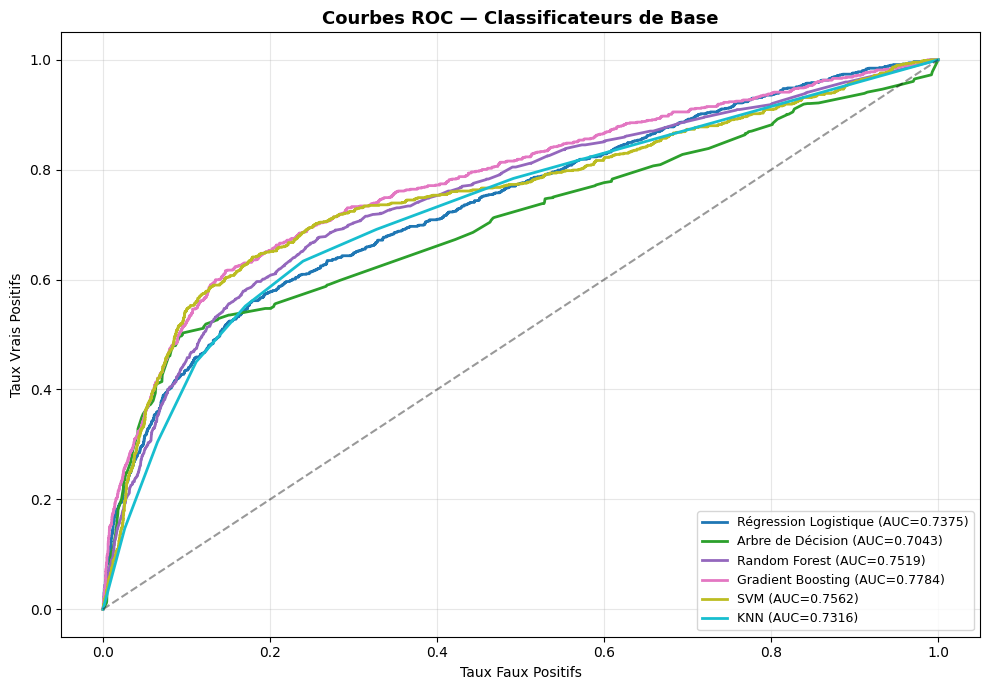

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for (name, clf), color in zip(trained_models.items(), colors):
    y_prob = clf.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_title('Courbes ROC — Classificateurs de Base', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux Faux Positifs')
ax.set_ylabel('Taux Vrais Positifs')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/phase2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Importance des Features (Random Forest + SHAP)

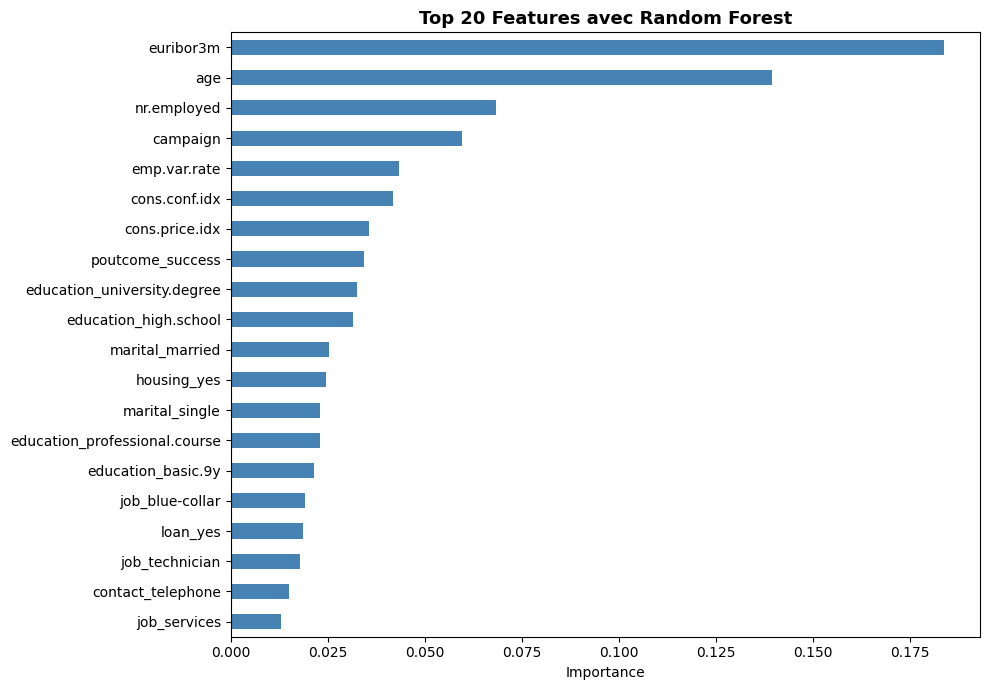

In [25]:
rf = trained_models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features avec Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/phase2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Sauvegarde des résultats pour Phase 3
df_test_save = pd.DataFrame(list(results_test.values()))
df_test_save.to_csv('../models/results_phase2.csv', index=False)
print("Résultats sauvegardés dans models/results_phase2.csv")

Résultats sauvegardés dans models/results_phase2.csv


## Phase 3 : Ensembles de Modèles (Bagging, Boosting, Stacking)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               StackingClassifier)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                               average_precision_score, roc_curve,
                               classification_report, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
print("Imports OK")

Imports OK


## 1. Chargement des Données

In [30]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")

X_train : (54134, 42) | X_test : (7685, 42)


## 2. Bagging

In [31]:
print("Entraînement Bagging...")
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, class_weight='balanced'),
    n_estimators=200, max_samples=0.8, max_features=0.8,
    random_state=SEED, n_jobs=-1
)
bagging.fit(X_train, y_train)
y_prob_bag = bagging.predict_proba(X_test)[:,1]
y_pred_bag = bagging.predict(X_test)

bagging_metrics = {
    'Modèle': 'Bagging',
    'AUC-ROC': round(roc_auc_score(y_test, y_prob_bag), 4),
    'F1-Score': round(f1_score(y_test, y_pred_bag), 4),
    'Précision': round(precision_score(y_test, y_pred), 4),
    'Recall': round(recall_score(y_test, y_pred), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_bag), 4),
    'Avg Precision': round(average_precision_score(y_test, y_prob_bag), 4),
}
print(f"Bagging -> AUC={bagging_metrics['AUC-ROC']} | F1={bagging_metrics['F1-Score']}")
joblib.dump(bagging, '../models/bagging.pkl')

Entraînement Bagging...
Bagging -> AUC=0.7785 | F1=0.4883


['../models/bagging.pkl']

## 3. Boosting : XGBoost & LightGBM avec GridSearch

In [32]:
# XGBoost
print("Tuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
}
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc',
                               random_state=SEED, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
xgb_gs = GridSearchCV(xgb_base, xgb_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train)
print(f"XGBoost meilleurs params : {xgb_gs.best_params_}")

y_prob_xgb = xgb_gs.best_estimator_.predict_proba(X_test)[:,1]
y_pred_xgb = xgb_gs.best_estimator_.predict(X_test)
xgb_metrics = {
    'Modèle': 'XGBoost',
    'AUC-ROC': round(roc_auc_score(y_test, y_prob_xgb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_xgb), 4),
    'Précision': round(precision_score(y_test, y_pred), 4),
    'Recall': round(recall_score(y_test, y_pred), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_xgb), 4),
    'Avg Precision': round(average_precision_score(y_test, y_prob_xgb), 4),
}
print(f"XGBoost -> AUC={xgb_metrics['AUC-ROC']} | F1={xgb_metrics['F1-Score']}")
joblib.dump(xgb_gs.best_estimator_, '../models/xgboost_best.pkl')

Tuning XGBoost...
XGBoost meilleurs params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
XGBoost -> AUC=0.7749 | F1=0.4384


['../models/xgboost_best.pkl']

In [33]:
# LightGBM
print("Tuning LightGBM...")
lgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
}
lgb_base = lgb.LGBMClassifier(random_state=SEED, class_weight='balanced', verbose=-1)
lgb_gs = GridSearchCV(lgb_base, lgb_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
lgb_gs.fit(X_train, y_train)
print(f"LightGBM meilleurs params : {lgb_gs.best_params_}")

y_prob_lgb = lgb_gs.best_estimator_.predict_proba(X_test)[:,1]
y_pred_lgb = lgb_gs.best_estimator_.predict(X_test)
lgb_metrics = {
    'Modèle': 'LightGBM',
    'AUC-ROC': round(roc_auc_score(y_test, y_prob_lgb), 4),
    'F1-Score': round(f1_score(y_test, y_pred_lgb), 4),
    'Précision': round(precision_score(y_test, y_pred), 4),
    'Recall': round(recall_score(y_test, y_pred), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_lgb), 4),
    'Avg Precision': round(average_precision_score(y_test, y_prob_lgb), 4),
}
print(f"LightGBM : AUC={lgb_metrics['AUC-ROC']} | F1={lgb_metrics['F1-Score']}")
joblib.dump(lgb_gs.best_estimator_, '../models/lightgbm_best.pkl')

Tuning LightGBM...
LightGBM meilleurs params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'num_leaves': 63}
LightGBM : AUC=0.7854 | F1=0.4486


['../models/lightgbm_best.pkl']

4. Stacking

In [36]:
print("Entraînement Stacking...")
base_estimators = [
    ('rf',  joblib.load('../models/random_forest.pkl')),
    ('xgb', xgb_gs.best_estimator_),
    ('lgb', lgb_gs.best_estimator_),
]
meta_clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
stacking = StackingClassifier(
    estimators=base_estimators, final_estimator=meta_clf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    passthrough=False, n_jobs=-1
)
stacking.fit(X_train, y_train)
y_prob_stack = stacking.predict_proba(X_test)[:,1]
y_pred_stack = stacking.predict(X_test)

stacking_metrics = {
    'Modèle': 'Stacking',
    'AUC-ROC': round(roc_auc_score(y_test, y_prob_stack), 4),
    'F1-Score': round(f1_score(y_test, y_pred_stack), 4),
    'Précision': round(precision_score(y_test, y_pred), 4),
    'Recall': round(recall_score(y_test, y_pred), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_stack), 4),
    'Avg Precision': round(average_precision_score(y_test, y_prob_stack), 4),
}
print(f"Stacking : AUC={stacking_metrics['AUC-ROC']} | F1={stacking_metrics['F1-Score']}")
joblib.dump(stacking, '../models/stacking.pkl')

Entraînement Stacking...
Stacking : AUC=0.7706 | F1=0.4132


['../models/stacking.pkl']

## 5. Comparaison des Ensembles

In [38]:
# Chargement résultats Phase 2
df_phase2 = pd.read_csv('../models/results_phase2.csv')
df_phase3 = pd.DataFrame([bagging_metrics, xgb_metrics, lgb_metrics, stacking_metrics])

df_all_so_far = pd.concat([df_phase2, df_phase3], ignore_index=True)
df_all_so_far = df_all_so_far.sort_values('AUC-ROC', ascending=False)

print("Comparaison Phase 2 + Phase 3 :")
display(df_all_so_far.style
    .highlight_max(subset=['AUC-ROC','F1-Score', 'Précision', 'Recall', 'Accuracy','Avg Precision'], color="#06791d")
    .format({'AUC-ROC':'{:.4f}','F1-Score':'{:.4f}', 'Précision':'{:.4f}',
         'Recall':'{:.4f}', 'Accuracy':'{:.4f}','Avg Precision':'{:.4f}'})
    .set_caption('Comparaison Phases 2 & 3 sur le Jeu de Test'))

Comparaison Phase 2 + Phase 3 :


,Modèle,AUC-ROC,F1-Score,Précision,Recall,Accuracy,Avg Precision
8,LightGBM,0.7854,0.4486,0.3050,0.5518,0.8759,0.4177
6,Bagging,0.7785,0.4883,0.3050,0.5518,0.8634,0.4277
3,Gradient Boosting,0.7784,0.4644,0.4113,0.5333,0.8532,0.4205
7,XGBoost,0.7749,0.4384,0.3050,0.5518,0.8707,0.4025
9,Stacking,0.7706,0.4132,0.3050,0.5518,0.8703,0.3904
4,SVM,0.7562,0.3709,0.2495,0.7219,0.7077,0.3638
2,Random Forest,0.7519,0.3952,0.4149,0.3773,0.8622,0.3467
0,Régression Logistique,0.7375,0.3945,0.3260,0.4995,0.8170,0.3616
5,KNN,0.7316,0.3929,0.3050,0.5518,0.7965,0.2840
1,Arbre de Décision,0.7043,0.4542,0.4180,0.4973,0.8574,0.3432


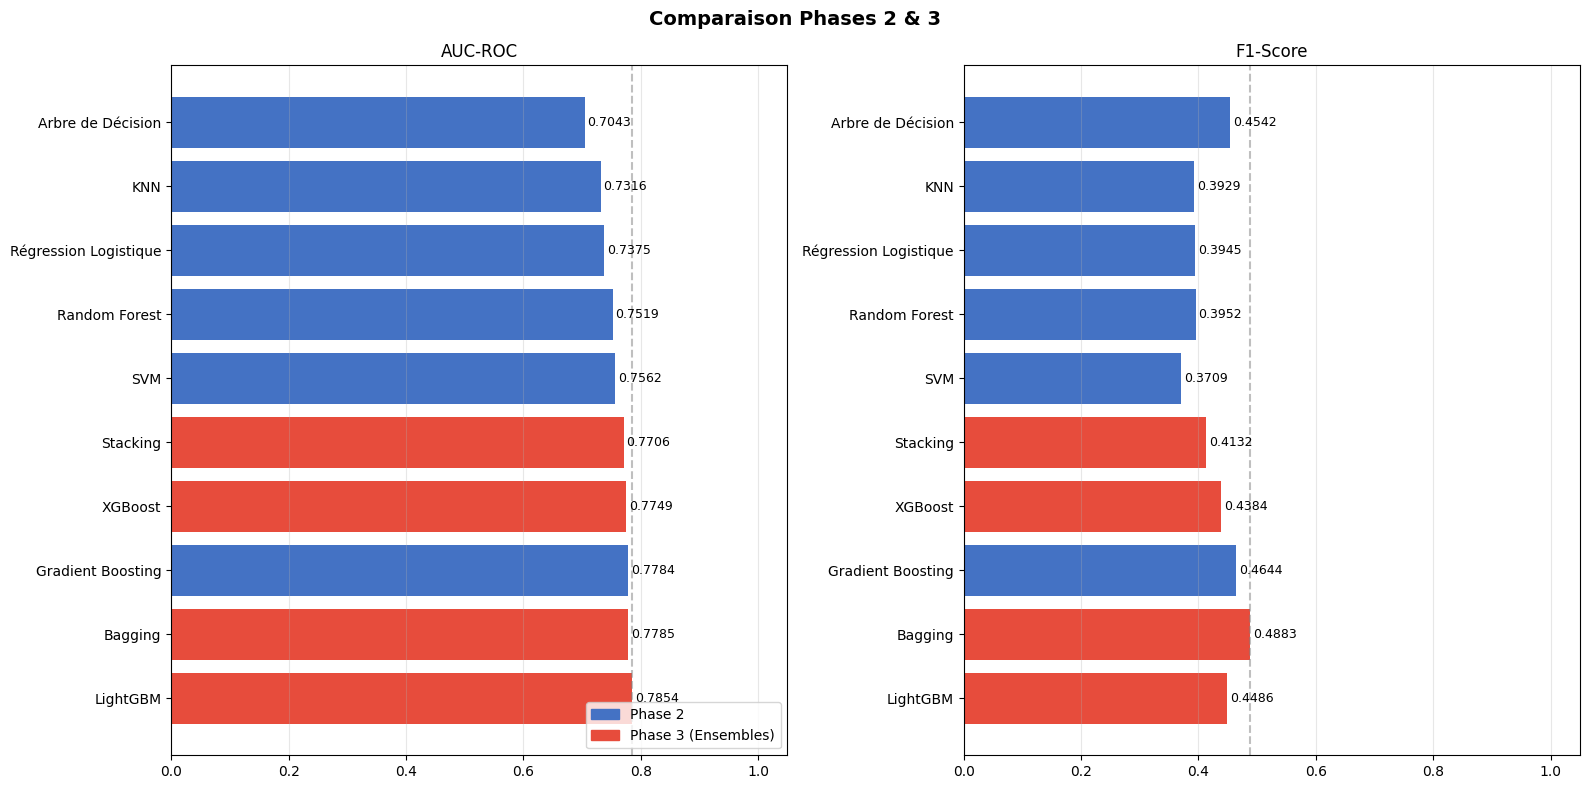

In [40]:
# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Comparaison Phases 2 & 3', fontsize=14, fontweight='bold')

phase3_models = ['Bagging','XGBoost','LightGBM','Stacking']
colors = ['#E74C3C' if m in phase3_models else '#4472C4' for m in df_all_so_far['Modèle']]

for ax, metric in zip(axes, ['AUC-ROC','F1-Score']):
    bars = ax.barh(df_all_so_far['Modèle'], df_all_so_far[metric], color=colors)
    ax.set_title(metric); ax.set_xlim(0, 1.05)
    ax.axvline(df_all_so_far[metric].max(), color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, df_all_so_far[metric]):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4472C4',label='Phase 2'),
                         Patch(color='#E74C3C',label='Phase 3 (Ensembles)')], loc='lower right')
plt.tight_layout()
plt.savefig('../results/phase3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Sauvegarde résultats phases 1-3 pour Phase 4
df_all_so_far.to_csv('../models/results_phases3.csv', index=False)
print("Résultats sauvegardés dans models/results_phases3.csv")

Résultats sauvegardés dans models/results_phases3.csv
